In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


from credit_default.utils import get_models_and_routes
from credit_default.evaluation import (
    score_modelo_lineal,
    score_modelo_no_lineal,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve
)

from credit_default.features import (
    load_checkpoint
)

from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
nombre_checkpoint = 'vif_checkpoint'
checkpoints_path = PROJECT_ROOT / 'checkpoints' / nombre_checkpoint

arreglo_frames, json_loaded = load_checkpoint(checkpoints_path)

model_list, lista_nombres = get_models_and_routes()
numero_modelos = len(model_list)

X_train, X_test, y_train, y_test = arreglo_frames

Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/X_train.parquet
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/X_test.parquet
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/y_train.parquet
Aplanando y_train
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/y_test.parquet
Aplanando y_test
Preparando modelos ... /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit
Leyendo la ruta /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/models/logistic_np1log/lr_np1log.joblib
Modelo cargado lr_np1log.joblib.
Leyendo la ruta /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit

In [3]:
model_np1log = model_list[0]
model_xgb = model_list[1]
model_raw = model_list[2]

In [4]:
model_np1log

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log1p_num', ...), ('yeo', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [5]:
model_raw

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [6]:
model_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [7]:
modelos_listado = ['reg_np1log', 'reg_baseline', 'xgboost']
i = 0

modelos_rendimiento = {}

for model in model_list:

    y_pred = model.predict(X_test)
    y_probas = model.predict_proba(X_test)[:, 1]
    CM, F1, ACCURACY, ROCAUC, RECALL, PRECISION, PR_AUC = score_modelo_no_lineal(y_test, y_pred)
    data = {
        'CM' : CM,
        'F1' : F1,
        'ACCURACY' : ACCURACY,
        'PRECISION' : PRECISION,
        'ROCAUC' : ROCAUC,
        'RECALL' : RECALL,
        'PR_AUC' : PR_AUC,
        'Y_TRUE' : y_test,
        'Y_PRED' : y_pred,
        'SCORES' : y_probas
    }
    modelos_rendimiento[modelos_listado[i]] = data
    i += 1


Entrando a Predecir
Entrando a Predecir
Entrando a Predecir


In [8]:
frame = pd.DataFrame(modelos_rendimiento)

frame = frame.drop(['CM','SCORES', 'Y_TRUE', 'Y_PRED'],)

frame

,reg_np1log,reg_baseline,xgboost
F1,0.51235,0.465049,0.513089
ACCURACY,0.76959,0.816272,0.767422
PRECISION,0.481752,0.653479,0.477893
ROCAUC,0.689948,0.653293,0.690985
RECALL,0.547099,0.360965,0.553881
PR_AUC,0.363766,0.377263,0.363396


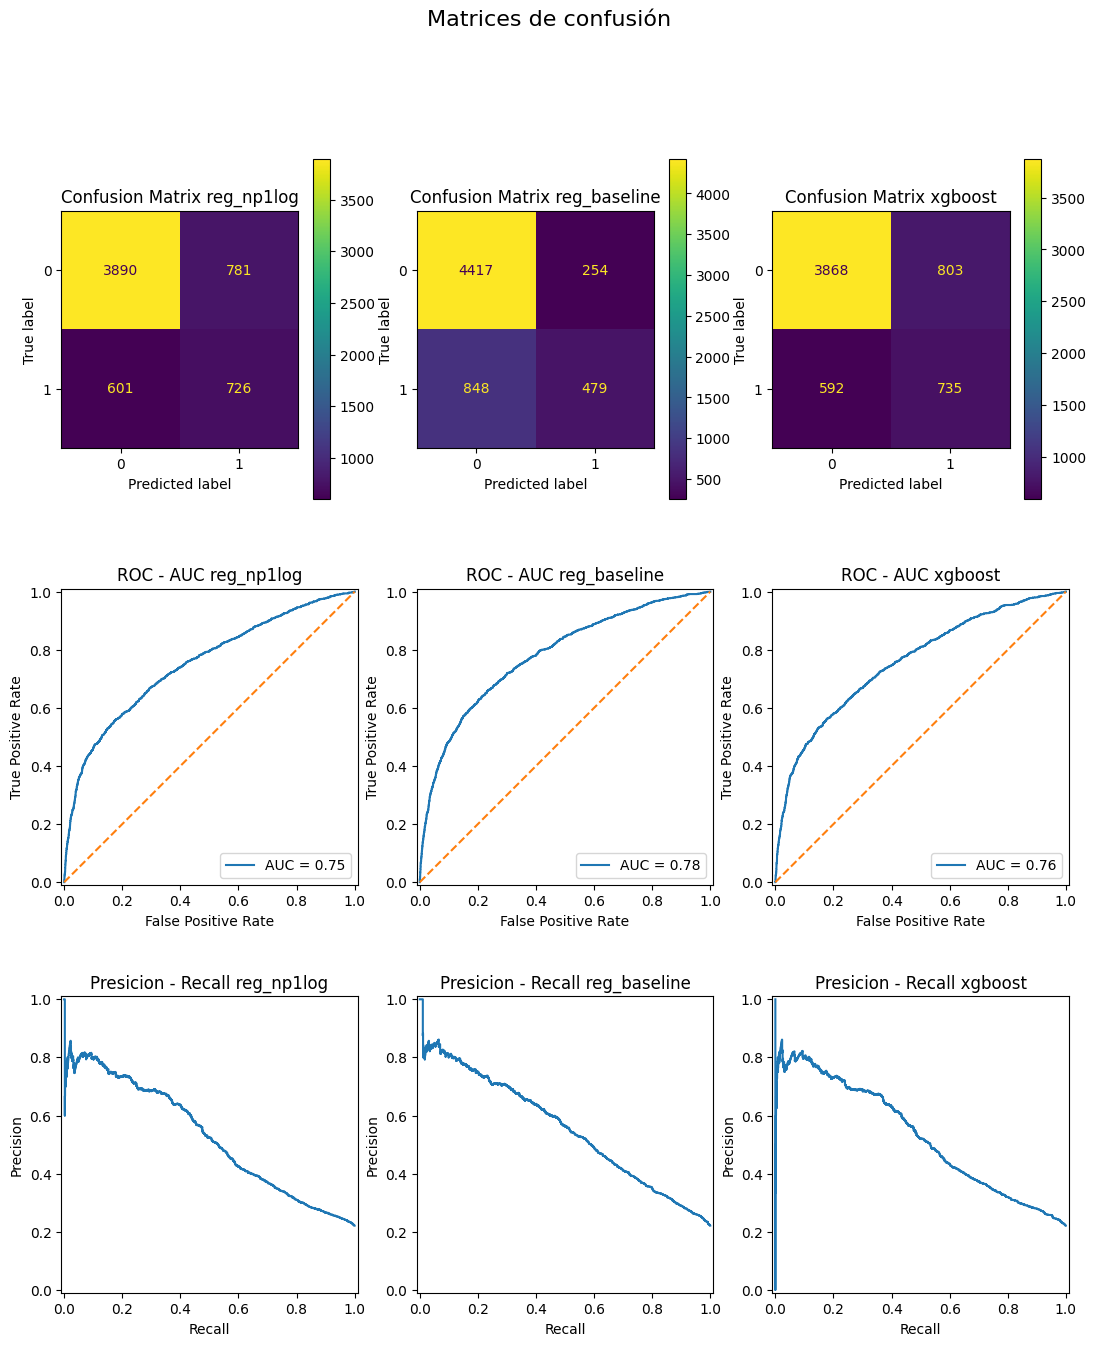

In [9]:
## Ploting

filas = 3
columnas = 3

fig, axes = plt.subplots(filas, columnas, figsize = (13,15))

columna_index = 0
fila = 0

for nombre_modelo, calificaciones in modelos_rendimiento.items():
    
    plot_confusion_matrix(calificaciones['CM'], axes = axes[columna_index, fila])
    axes[columna_index, fila].set_title(f'Confusion Matrix {nombre_modelo}')

    plot_roc_curve(calificaciones['Y_TRUE'], calificaciones['SCORES'], axes = axes[1, fila])
    axes[1, fila].set_title(f'ROC - AUC {nombre_modelo}')

    plot_precision_recall_curve(calificaciones['Y_TRUE'], calificaciones['SCORES'], axes = axes[2, fila])
    axes[2, fila].set_title(f'Presicion - Recall {nombre_modelo}')

    fila += 1



fig.suptitle('Matrices de confusión', fontsize = 16)
plt.show()